In [ ]:
import torch
from torch.optim import Optimizer

class CustomOptimizer(Optimizer):
    def __init__(self, params, lr=0.01, momentum=0.9, weight_decay=0):
        """
        Initialize the CustomOptimizer

        Args:
            params (iterable): Iterable of parameters to optimize
            lr (float): Learning rate (default: 0.01)
            momentum (float): Momentum factor (default: 0.9)
            weight_decay (float): Weight decay coefficient (default: 0)
        """
        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay)
        super(CustomOptimizer, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        """
        Perform a single optimization step

        Args:
            closure (callable, optional): A closure that reevaluates the model
                                          and returns the loss
        Returns:
            loss: The loss value returned by the closure, if provided
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            weight_decay = group['weight_decay']

            for p in group['params']:
                if p.grad is None:
                    continue

                d_p = p.grad

                if weight_decay != 0:
                    d_p = d_p.add(p, alpha=weight_decay)
                param_state = self.state[p]
                if 'momentum_buffer' not in param_state:
                    buf = param_state['momentum_buffer'] = torch.clone(d_p).detach()
                else:
                    buf = param_state['momentum_buffer']
                    buf.mul_(momentum).add_(d_p)

                p.add_(buf, alpha=-lr)

        return loss


In [ ]:
import torch
from torch.optim import Optimizer
import math

class DiagonalAdaGrad(Optimizer):
    """Implements the diagonal version of AdaGrad algorithm.

    This optimizer adapts the learning rate for each parameter based on
    historical gradient information, giving frequently occurring features
    very low learning rates and infrequent features high learning rates.

    Args:
        params (iterable): iterable of parameters to optimize
        lr (float, optional): learning rate (default: 1.0)
        eps (float, optional): term added to the denominator to improve
            numerical stability (default: 1e-10)
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
    """

    def __init__(self, params, lr=1.0, eps=1e-10, weight_decay=0):
        if lr <= 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps <= 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if weight_decay < 0.0:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")

        defaults = dict(lr=lr, eps=eps, weight_decay=weight_decay)
        super(DiagonalAdaGrad, self).__init__(params, defaults)

    def step(self, closure=None):
        """Performs a single optimization step.

        Args:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.data
                state = self.state[p]

                if len(state) == 0:
                    state['sum'] = torch.zeros_like(p.data)

                if group['weight_decay'] != 0:
                    grad = grad.add(p.data, alpha=group['weight_decay'])

                state['sum'].addcmul_(grad, grad, value=1)

                std = state['sum'].sqrt().add_(group['eps'])
                p.data.addcdiv_(grad, std, value=-group['lr'])

        return loss


In [ ]:
import torch
from torch.optim import Optimizer
import math

class FullMatrixAdaGrad(Optimizer):
    """Implements the full-matrix version of AdaGrad algorithm.

    This optimizer adapts the learning rate using the full matrix of outer
    products of gradients, capturing correlations between parameters.

    Args:
        params (iterable): iterable of parameters to optimize
        lr (float, optional): learning rate (default: 1.0)
        eps (float, optional): term added to the denominator to improve
            numerical stability (default: 1e-10)
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
    """

    def __init__(self, params, lr=1.0, eps=1e-10, weight_decay=0):
        if lr <= 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps <= 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if weight_decay < 0.0:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")

        defaults = dict(lr=lr, eps=eps, weight_decay=weight_decay)
        super(FullMatrixAdaGrad, self).__init__(params, defaults)

    def _compute_inv_matrix_sqrt(self, matrix, eps):
        """Compute the inverse square root of a positive semi-definite matrix."""
        eigenvalues, eigenvectors = torch.linalg.eigh(matrix)

        inv_sqrt_eigenvalues = 1.0 / torch.sqrt(torch.clamp(eigenvalues, min=eps))
        inv_sqrt_matrix = eigenvectors @ torch.diag(inv_sqrt_eigenvalues) @ eigenvectors.t()

        return inv_sqrt_matrix

    def step(self, closure=None):
        """Performs a single optimization step.

        Args:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.data
                state = self.state[p]

                original_shape = p.data.shape
                grad_vector = grad.reshape(-1)
                param_vector = p.data.reshape(-1)

                if len(state) == 0:
                    state['G'] = torch.zeros(len(grad_vector), len(grad_vector),
                                           device=grad.device, dtype=grad.dtype)

                if group['weight_decay'] != 0:
                    grad_vector = grad_vector.add(param_vector, alpha=group['weight_decay'])

                # Update G matrix with outer product of gradient
                outer_product = grad_vector.unsqueeze(1) @ grad_vector.unsqueeze(0)
                state['G'].add_(outer_product)

                # Compute G^(1/2) - the square root of G
                G_inv_sqrt = self._compute_inv_matrix_sqrt(state['G'], group['eps'])

                # Compute update: -lr * G^(-1/2) * gradient
                update = -group['lr'] * (G_inv_sqrt @ grad_vector)

                # Update parameters
                param_vector.add_(update)

                # Reshape parameters back to original shape
                p.data = param_vector.reshape(original_shape)

        return loss


In [ ]:
import torch
from torch.optim import Optimizer
import math

class AdaGram(Optimizer):
    """Implements the full-matrix version of AdaGrad algorithm using recursive factorization.

    This optimizer adapts the learning rate using the full matrix of outer
    products of gradients, capturing correlations between parameters.

    The implementation uses the recursive formula G_t = L_t L_t^T where L_t
    is updated efficiently at each step without computing the full matrix inverse.

    Args:
        params (iterable): iterable of parameters to optimize
        lr (float, optional): learning rate (default: 1.0)
        eps (float, optional): term added to the denominator to improve
            numerical stability (default: 1e-10)
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
        max_rank (int, optional): maximum rank to maintain for U and V matrices (default: None)
    """

    def __init__(self, params, lr=1.0, eps=1e-10, weight_decay=0, max_rank=None):
        if lr <= 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps <= 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if weight_decay < 0.0:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")

        defaults = dict(lr=lr, eps=eps, weight_decay=weight_decay, max_rank=max_rank)
        super(AdaGram, self).__init__(params, defaults)

    def _compute_alpha(self, g_bar_norm_sq, eps):
        """Compute alpha_t that satisfies the equation (6) in the theorem."""
        # 1 + alpha_t*||g_bar_t||^2 = (1 + ||g_bar_t||^2)^(1/2)
        # Solving for alpha_t:
        # alpha_t = ((1 + ||g_bar_t||^2)^(1/2) - 1) / ||g_bar_t||^2
        return ((1 + g_bar_norm_sq).sqrt() - 1) / (g_bar_norm_sq + eps)

    def _compute_beta(self, alpha, g_bar_norm_sq):
        """Compute beta_t as defined in the theorem."""
        return alpha / (1 + alpha * g_bar_norm_sq)

    def step(self, closure=None):
        """Performs a single optimization step.

        Args:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            eps = group['eps']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.data
                state = self.state[p]

                original_shape = p.data.shape
                grad_vector = grad.reshape(-1)
                param_vector = p.data.reshape(-1)
                n = len(grad_vector)

                if len(state) == 0:
                    state['U'] = torch.zeros(n, 0, device=grad.device, dtype=grad.dtype)
                    state['V'] = torch.zeros(n, 0, device=grad.device, dtype=grad.dtype)
                    state['L0_inv'] = torch.eye(n, device=grad.device, dtype=grad.dtype) / math.sqrt(eps)

                if group['weight_decay'] != 0:
                    grad_vector = grad_vector.add(param_vector, alpha=group['weight_decay'])

                # Compute g_bar = L_t^(-1) * g_t+1
                # Using the recursive formula from equation (8) in Lemma 1:
                # L_t^(-1) = (I - U_t * V_t^T) * L_0^(-1)

                # First apply L_0^(-1) = (1/sqrt(eps)) * I
                g_bar = state['L0_inv'] @ grad_vector

                # Then apply (I - U_t * V_t^T)
                if state['U'].shape[1] > 0:  # Check if U_t is not empty
                    g_bar = g_bar - state['U'] @ (state['V'].t() @ g_bar)

                # Compute ||g_bar||^2
                g_bar_norm_sq = torch.dot(g_bar, g_bar)

                # Compute alpha_t according to equation (6)
                alpha = self._compute_alpha(g_bar_norm_sq, eps)

                # Compute beta_t
                beta = self._compute_beta(alpha, g_bar_norm_sq)

                # Update U_{t+1} and V_{t+1} according to equation (9)
                # U_{t+1} = [U_t  beta_{t+1}*g_{t+1}]
                # V_{t+1} = [V_t  g_bar_{t+1}]

                # Scale beta_g by L_0^(-1) since it's applied to g_{t+1}
                beta_g = beta * (state['L0_inv'] @ grad_vector)

                # Reshape to column vectors for concatenation
                beta_g = beta_g.reshape(-1, 1)
                g_bar_col = g_bar.reshape(-1, 1)

                # Update U and V
                state['U'] = torch.cat([state['U'], beta_g], dim=1)
                state['V'] = torch.cat([state['V'], g_bar_col], dim=1)

                # Limit the rank if max_rank is specified
                max_rank = group.get('max_rank')
                if max_rank is not None and state['U'].shape[1] > max_rank:
                    state['U'] = state['U'][:, -max_rank:]
                    state['V'] = state['V'][:, -max_rank:]

                # Compute the preconditioned gradient using equation (4):
                # L_{t+1}^(-1) * g_{t+1} = (1/sqrt(1 + ||L_t^(-1)*g_{t+1}||^2)) * L_t^(-1)*g_{t+1}
                precond_grad = g_bar / torch.sqrt(1 + g_bar_norm_sq)
                param_vector.add_(-precond_grad, alpha=-group['lr'])

                p.data = param_vector.reshape(original_shape)

        return loss


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)


learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5]
num_epochs = 500

def generate_data(n_samples=100, noise=0.1):
    X = torch.rand(n_samples, 1) * 10
    y = 2 * X + 1 + noise * torch.randn(n_samples, 1)
    return X, y

X, y = generate_data(n_samples=300)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

optimizers = {
    'Diagonal Adagrad': lambda params, lr: DiagonalAdaGrad(params, lr=lr),
    'Full Matrix Adagrad': lambda params, lr: FullMatrixAdaGrad(params, lr=lr),
    'AdaGram': lambda params, lr: AdaGram(params, lr=lr),
    'Torch Adagrad': lambda params, lr: torch.optim.Adagrad(params, lr=lr),
    'Vanilla SGD': lambda params, lr: torch.optim.SGD(params, lr=lr)
}

models = {}
all_train_losses = {}
all_test_losses = {}

results = []

for opt_name, opt_fn in optimizers.items():
    for lr in learning_rates:
            model = LinearRegressionModel()
            criterion = nn.MSELoss()
            optimizer = opt_fn(model.parameters(), lr)
            for epoch in range(num_epochs):
                model.train()
                optimizer.zero_grad()
                y_pred = model(X_train)
                train_loss = criterion(y_pred, y_train)
                train_loss.backward()
                optimizer.step()
                results.append({
                'epoch': epoch,
                'optimizer': opt_name,
                'lr': lr,
                'loss': train_loss.detach().cpu().numpy()
            })
            model.eval()
            with torch.no_grad():
                y_pred_test = model(X_test)
                test_loss = criterion(y_pred_test, y_test).item()


In [ ]:
df = pd.DataFrame(results)
df['loss'] = df['loss'].astype(float)
df.head()

,epoch,optimizer,lr,loss
0,0,Diagonal Adagrad,0.001,139.125809
1,1,Diagonal Adagrad,0.001,138.976074
2,2,Diagonal Adagrad,0.001,138.870300
3,3,Diagonal Adagrad,0.001,138.783966
4,4,Diagonal Adagrad,0.001,138.709229


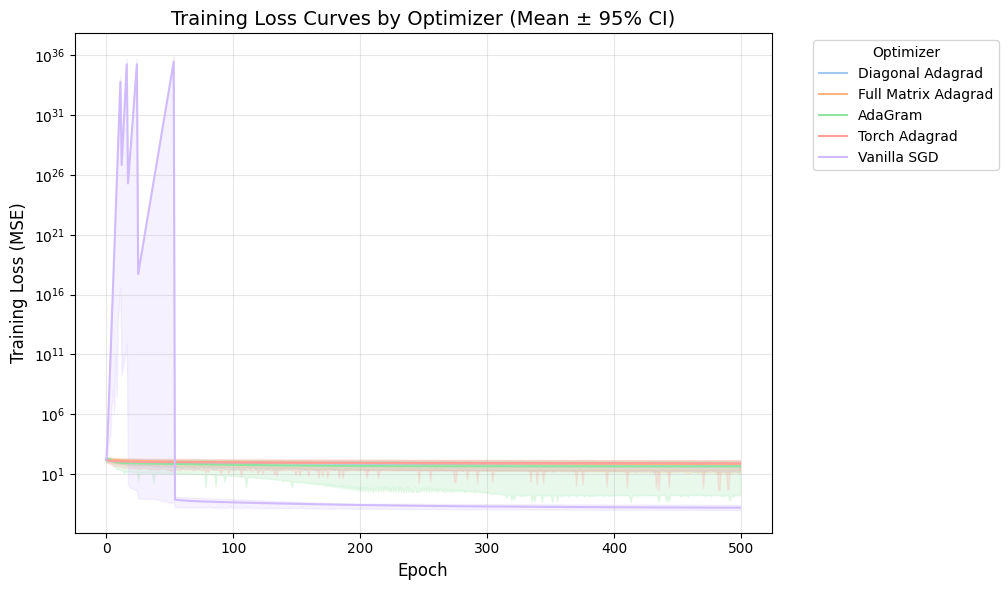

In [ ]:
import pandas as pd
import seaborn as sns

# df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x='epoch',
    y='loss',
    hue='optimizer',
    errorbar=('ci', 95),  # Explicit confidence interval specification
    # estimator='mean',      # Show mean across runs
    palette='pastel',     # Better color scheme
    linewidth=1.5
)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss (MSE)', fontsize=12)
plt.title('Training Loss Curves by Optimizer (Mean ± 95% CI)', fontsize=14)
plt.legend(title='Optimizer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# # Separate plot for test loss vs learning rate
# plt.figure(figsize=(12, 6))
# sns.lineplot(
#     data=df,
#     x='lr',
#     y='loss',
#     hue='optimizer',
#     errorbar=('ci', 95),
#     marker='o',
#     markersize=8,
#     palette='viridis'
# )

plt.yscale('log')
# plt.xlabel('Learning Rate (log scale)', fontsize=12)
# plt.ylabel('Test Loss (MSE)', fontsize=12)
# plt.title('Test Loss vs Learning Rate (Mean ± 95% CI)', fontsize=14)
# plt.legend(title='Optimizer', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()

plt.show()



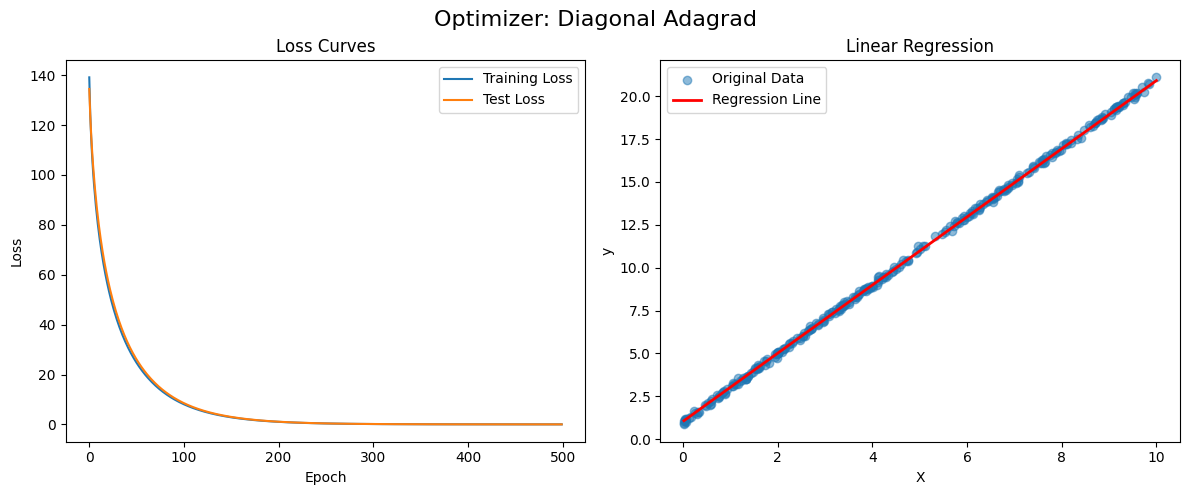

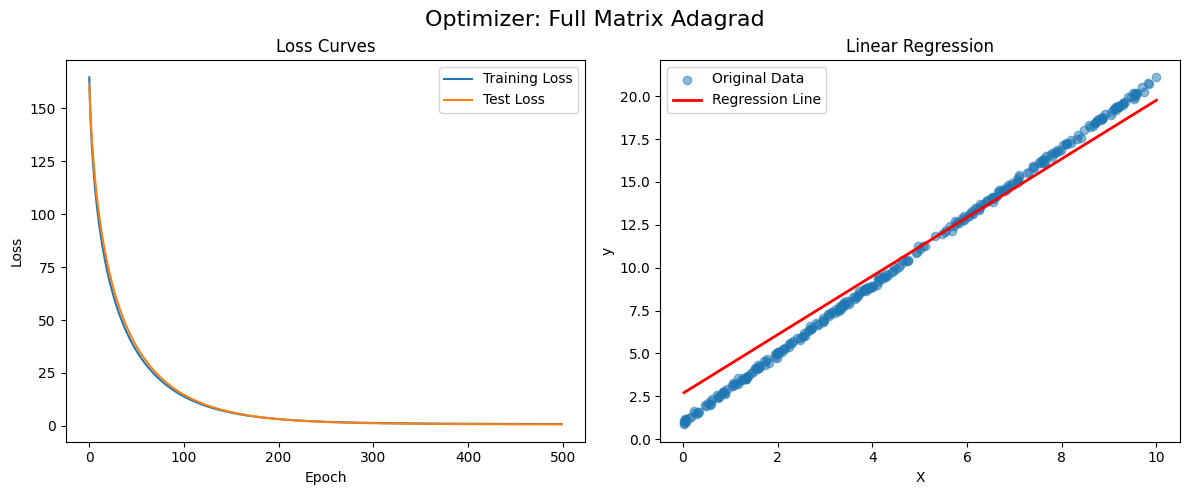

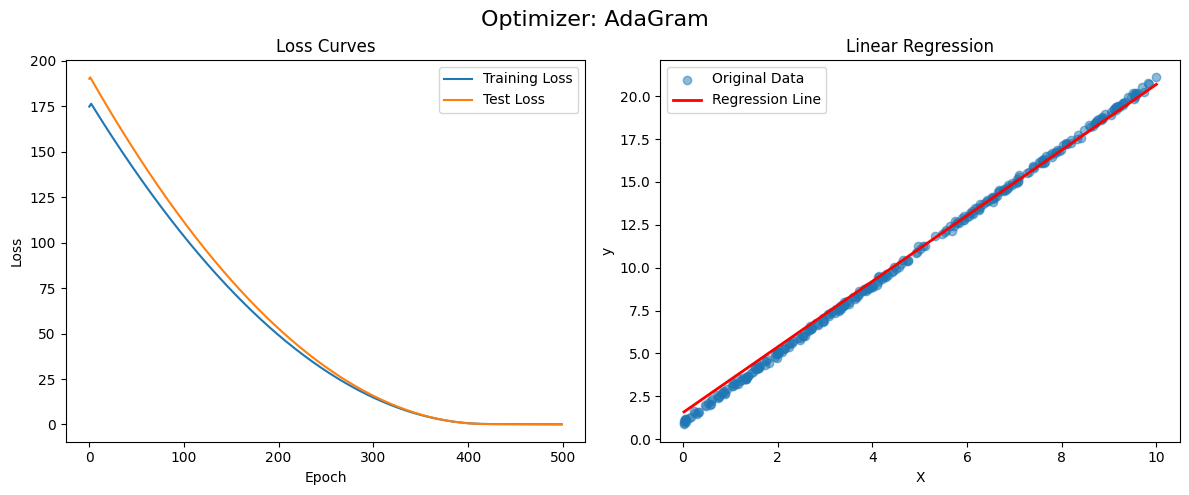

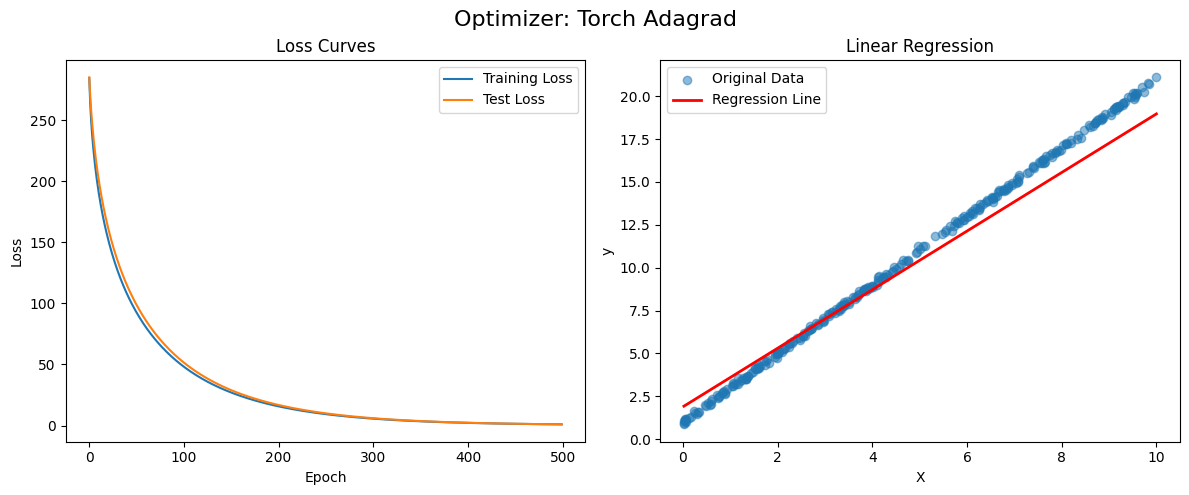

In [ ]:
for opt in optimizers.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Optimizer: {opt}', fontsize=16)

    ax1.plot(all_train_losses[opt], label='Training Loss')
    ax1.plot(all_test_losses[opt], label='Test Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Curves')
    ax1.legend()

    sorted_indices = torch.argsort(X.flatten())
    X_sorted = X[sorted_indices]
    y_sorted = y[sorted_indices]
    y_pred_sorted = models[opt](X_sorted)

    ax2.scatter(X.numpy(), y.numpy(), alpha=0.5, label='Original Data')
    ax2.plot(X_sorted.numpy(), y_pred_sorted.numpy(), 'r-', linewidth=2, label='Regression Line')
    ax2.set_xlabel('X')
    ax2.set_ylabel('y')
    ax2.set_title('Linear Regression')
    ax2.legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.savefig(f'{opt}_results.pdf')
    plt.show()
